# Detecting people in video, step by step

A walkthrough of the detection core in this repository: loading a pretrained
convolutional network, running it on a still, understanding what it actually
returns, and then working out why "number of detections" is not "number of
people".

The pipeline exists because of that last gap. A detector answers *what is in
this frame*. Audience analysis needs *how many distinct people passed through,
and for how long* — and the distance between those two questions is most of the
engineering here.

For how well any of it works, see
[`mot17_benchmark.ipynb`](mot17_benchmark.ipynb), which scores the whole thing
against a public benchmark. This notebook is about mechanism, not measurement.

In [1]:
import sys
from pathlib import Path

sys.path.insert(0, str(Path.cwd().parent))

import cv2
import matplotlib.pyplot as plt

from humandetect import config
from humandetect.detector import PersonDetector, draw, suppress

SAMPLES = Path.cwd().parent / "samples"

print(f"OpenCV {cv2.__version__}")

OpenCV 5.0.0


## 1. The model, and what its input settings mean

**SSD MobileNet v3 Large**, trained on COCO. Single Shot MultiBox Detector: one
forward pass produces class scores and box coordinates for a fixed grid of
anchor boxes, with no separate region-proposal stage. That is what makes it fast
enough to run per frame on a CPU.

It loads through OpenCV's DNN module, which reads the TensorFlow frozen graph
directly — so the network runs with neither TensorFlow nor PyTorch installed.
That matters for edge deployment, and it is why this backend is the default.

Four input settings have to match how the network was trained, or the output is
quietly wrong rather than loudly broken:

| setting | value | why |
|---|---|---|
| input size | 320×320 | what the graph was trained at; fixed, not tunable |
| scale | 1/127.5 | maps 0–255 pixel values onto a 0–2 range |
| mean | (127.5, 127.5, 127.5) | subtracted after scaling, shifting to −1…1 |
| swap R/B | True | OpenCV loads BGR; the network expects RGB |

Get the mean or scale wrong and the network still returns detections — just
poor ones. There is no error to catch, which is exactly why these live in
`config.py` as named constants rather than as literals at a call site.

In [2]:
print(f"input size   {config.INPUT_SIZE}")
print(f"input scale  {config.INPUT_SCALE:.6f}   (1/127.5)")
print(f"input mean   {config.INPUT_MEAN}")
print(f"person class {config.PERSON_CLASS_ID} of {len(open(config.LABELS_FILE).read().splitlines())} COCO classes")

detector = PersonDetector()   # applies all four settings, downloads weights if needed
print("\nmodel loaded")

input size   (320, 320)
input scale  0.007843   (1/127.5)
input mean   (127.5, 127.5, 127.5)
person class 1 of 80 COCO classes

model loaded


## 2. Detection on a still

`detect()` returns a list of `Detection` objects rather than the three parallel
arrays OpenCV hands back. Parallel arrays are a standing invitation to index one
of them incorrectly; a list of records with named fields is not.

`people_only=False` here so the full COCO output is visible.

In [3]:
image = cv2.imread(str(SAMPLES / "manbenz.png"))

raw = detector.detect(image, confidence_threshold=0.5,
                      people_only=False, deduplicate=False)

print(f"{len(raw)} raw detections\n")
for d in raw:
    print(f"  {d.label:<12} {d.confidence:.3f}  box={d.box}")

5 raw detections

  person       0.748  box=(81, 106, 82, 95)
  car          0.713  box=(70, 68, 186, 100)
  person       0.517  box=(78, 84, 126, 112)
  car          0.508  box=(184, 51, 32, 16)
  person       0.505  box=(69, 70, 182, 111)


## 3. The same object, counted more than once

The image contains one person and one car. The network reports more than that.

This is not a confidence problem — the duplicates score highly. SSD predicts
from a grid of anchor boxes, and several neighbouring anchors can each fire on
the same object. Non-maximum suppression is supposed to collapse those.

OpenCV's `dnn_DetectionModel.detect()` takes an `nmsThreshold` argument, and
**with this model it does nothing.** Sweeping it from 0.6 down to 0.1 returns
identical output at every value. So suppression is implemented directly in
`detector.py`.

It scores candidate pairs on two quantities, not one:

- **IoU** — intersection over union, the standard overlap measure
- **containment** — intersection over the *smaller* box's area

Containment is the one that matters here. A small box sitting almost entirely
inside a large one can have high containment and low IoU, so an IoU-only rule
keeps it and the object stays double-counted.

In [4]:
from humandetect.detector import _iou_and_containment

people = [d for d in raw if d.is_person]
for a, b in [(people[i], people[j])
             for i in range(len(people)) for j in range(i + 1, len(people))]:
    iou, containment = _iou_and_containment(a.box, b.box)
    print(f"IoU {iou:.3f}   containment {containment:.3f}   "
          f"{a.confidence:.2f} vs {b.confidence:.2f}")

IoU 0.508   containment 0.947   0.75 vs 0.52
IoU 0.282   containment 0.789   0.75 vs 0.51
IoU 0.553   containment 0.866   0.52 vs 0.51


In [5]:
kept = suppress(raw)

before = {}
after = {}
for d in raw:
    before[d.label] = before.get(d.label, 0) + 1
for d in kept:
    after[d.label] = after.get(d.label, 0) + 1

print(f"{'label':<12}{'raw':>6}{'suppressed':>12}")
for label in sorted(before):
    print(f"{label:<12}{before[label]:>6}{after.get(label, 0):>12}")

label          raw  suppressed
car              2           2
person           3           1


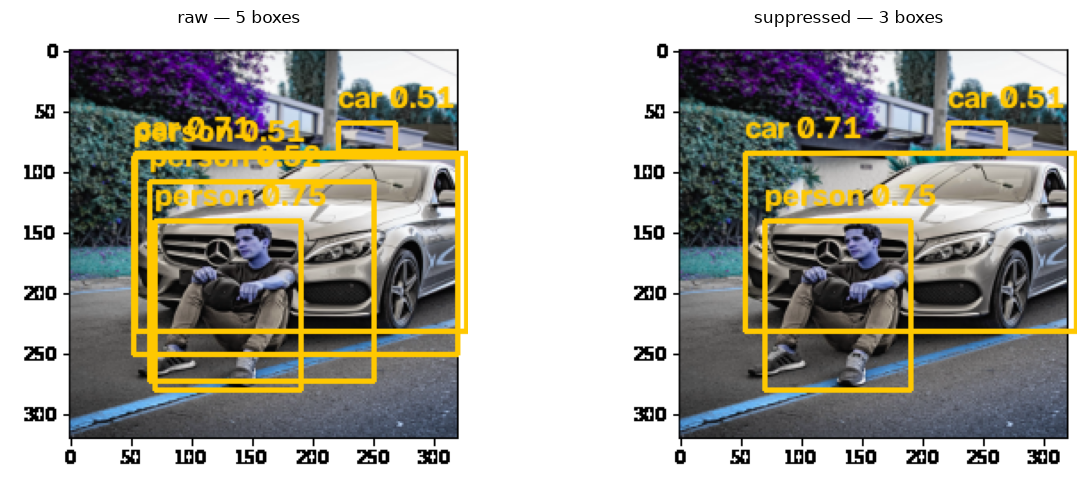

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
for ax, dets, title in [(axes[0], raw, f"raw — {len(raw)} boxes"),
                        (axes[1], kept, f"suppressed — {len(kept)} boxes")]:
    ax.imshow(cv2.cvtColor(draw(image, dets), cv2.COLOR_BGR2RGB))
    ax.set_title(title)
    ax.axis("off")
plt.tight_layout()
plt.show()

A caveat worth carrying forward, because the benchmark later proved it matters:
**this rule is right for duplicates and wrong for crowds.** A person standing
behind another person is genuinely 70%+ contained by them, and the rule cannot
tell that case from a duplicate box. On MOT17 it deletes real people. See the
benchmark notebook, where that costs measurable recall.

Validating a rule on an image containing one person is how a defect like that
survives.

## 4. Video, and the counting problem

Running the detector over every frame is straightforward. Interpreting the
result is not.

Over this 2.3-minute clip the detector produces roughly 20,000 person boxes
across 4,094 frames. That is emphatically **not** 20,000 people. Someone who
walks across the shot for four seconds contributes about 120 boxes at 30 fps.

"5 people per frame" is a debug print. "N distinct people passed through, median
dwell D seconds" is an audience metric. Getting from the first to the second is
what tracking does — and the next section produces the actual numbers rather
than quoting them here.

**The clip itself is not in this repository.** It is street footage containing
members of the public who did not consent to appearing in a public repository,
which is a privacy problem rather than a file-size one. Set `VIDEO` below to
any clip of your own; a fixed camera on a doorway or corridor works best, for
reasons `samples/README.md` goes into.

In [7]:
# Not distributed with the repository: it is street footage of members of
# the public, and publishing that is a privacy problem rather than a file
# size one. Point VIDEO at any clip of your own to run this section.
VIDEO = SAMPLES / "Samplevideo2.mp4"
if not VIDEO.is_file():
    raise FileNotFoundError(
        f"{VIDEO} not found. This clip is not committed — set VIDEO to any "
        f"video of your own. A fixed camera on a doorway works best."
    )

capture = cv2.VideoCapture(str(VIDEO))
if not capture.isOpened():
    raise RuntimeError(f"cannot open {VIDEO}")

fps = capture.get(cv2.CAP_PROP_FPS)
total = int(capture.get(cv2.CAP_PROP_FRAME_COUNT))
print(f"{total} frames at {fps:.1f} fps = {total / fps:.1f} seconds")

# Sample every 30th frame: enough to characterise the clip in seconds
# rather than minutes, and this cell is illustrative, not a measurement.
counts = []
frame_index = 0
while True:
    ok, frame = capture.read()
    if not ok:
        break
    if frame_index % 30 == 0:
        counts.append(len(detector.detect(frame, confidence_threshold=0.5)))
    frame_index += 1
capture.release()

print(f"sampled {len(counts)} frames")
print(f"person boxes: total {sum(counts)}, mean {sum(counts) / len(counts):.2f} per frame, max {max(counts)}")

4094 frames at 30.0 fps = 136.5 seconds
sampled 137 frames
person boxes: total 693, mean 5.06 per frame, max 17


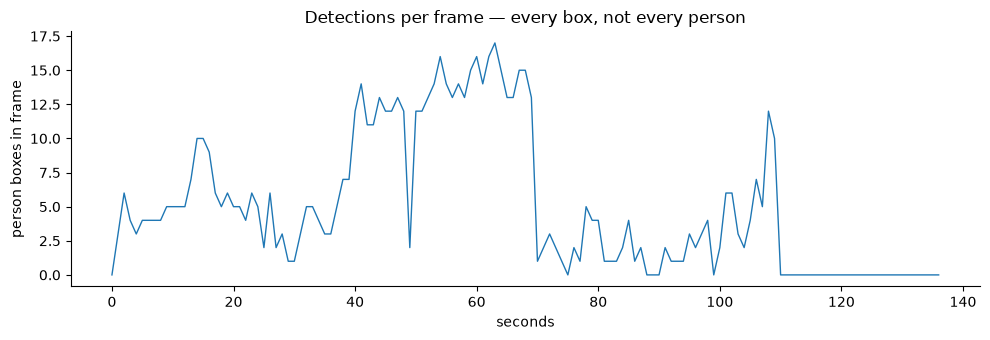

In [8]:
fig, ax = plt.subplots(figsize=(10, 3.5))
ax.plot([i * 30 / fps for i in range(len(counts))], counts, lw=1)
ax.set_xlabel("seconds"); ax.set_ylabel("person boxes in frame")
ax.set_title("Detections per frame — every box, not every person")
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.show()

## 5. From boxes to people

`PersonTracker` assigns each detection to an existing identity or starts a new
one. Matching is greedy on IoU, with a centroid-distance fallback for when boxes
do not overlap at all — a fast walker at a low frame rate — and a tolerance for
frames where a person is missed entirely, so walking behind an obstruction does
not mint a new identity on the far side.

Two parameters carry most of the behaviour:

- `TRACK_MAX_MISSING` — frames a track survives unmatched. Too low and one
  person becomes several; too high and two people become one.
- `TRACK_MIN_FRAMES` — tracks shorter than this are treated as detector
  flicker rather than people.

There is no motion model. That is a deliberate simplification and it has a
visible cost: two people crossing paths can swap identities, because nothing
predicts where each was heading. A Kalman filter is the standard fix, and the
benchmark notebook quantifies what its absence costs.

In [9]:
import math

from humandetect.tracking import PersonTracker

capture = cv2.VideoCapture(str(VIDEO))
width = int(capture.get(cv2.CAP_PROP_FRAME_WIDTH))
height = int(capture.get(cv2.CAP_PROP_FRAME_HEIGHT))

tracker = PersonTracker(frame_diagonal=math.hypot(width, height))

# First 900 frames (~30 s) keeps this cell quick while still spanning
# several people entering and leaving.
LIMIT = 900
for frame_index in range(1, LIMIT + 1):
    ok, frame = capture.read()
    if not ok:
        break
    tracker.update(detector.detect(frame, confidence_threshold=0.5), frame_index)
capture.release()

people = tracker.people()
boxes_seen = sum(t.frames_seen for t in people)

print(f"{boxes_seen} person boxes  ->  {len(people)} distinct people")
print(f"\n{'id':>4}{'frames':>8}{'dwell (s)':>11}{'travelled (px)':>16}")
for t in sorted(people, key=lambda t: -t.frames_seen)[:10]:
    print(f"{t.track_id:>4}{t.frames_seen:>8}{t.frames_seen / fps:>11.1f}"
          f"{t.distance_travelled():>16.0f}")

4437 person boxes  ->  91 distinct people

  id  frames  dwell (s)  travelled (px)
  11     282        9.4            2772
  42     230        7.7             560
  50     220        7.3            1346
  44     213        7.1             442
   3     193        6.4            1032
  48     177        5.9             988
  54     161        5.4             477
  55     142        4.7             746
  75     126        4.2             777
  24     124        4.1             716


The ratio between those two numbers is the whole point. Boxes are what the
network produces; people are what the question was about.

The count it lands on is also too high, and visibly so — that many distinct
people do not pass through thirty seconds of this clip. Each identity here is
plausible frame to frame while the total is wrong, which is precisely the
failure that self-reported numbers cannot catch. The clip is an edited montage,
and every hard cut hands the tracker an unmatched frame; camera motion does the
same thing more subtly. Both are addressed elsewhere in the repository, and
neither was discovered by looking at output like this.

`distance_travelled` separates someone passing through from someone standing
still — the difference between a person walking past a display and a person
looking at it, which is what an audience metric is actually trying to capture.
And it comes from trajectory geometry, not from another trained model: a
classifier for something derivable from coordinates is a model you have to
train, validate and explain, in exchange for nothing.

## 6. Where this goes

The pieces above are the honest core: a pretrained detector, suppression the
library did not provide, and identity assignment across frames.

What none of it establishes is whether any of it is *right*. Every number in
this notebook is self-reported — the pipeline grading its own homework. That
gap is what [`mot17_benchmark.ipynb`](mot17_benchmark.ipynb) closes, by running
the same code against 112,297 human-annotated boxes with published metrics.

Two of the design decisions explained above turn out to be wrong under that
measurement, in ways that were invisible here. That is the argument for
benchmarking, and it is easier to make with the numbers in hand than in the
abstract.